# FlexiblePCA - Quick Example

Minimal example demonstrating FlexiblePCA with all built-in plotting methods.

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD, PCA

import flexible_pca
import importlib
importlib.reload(flexible_pca)
from flexible_pca import FlexiblePCA, TrialSpec, create_standard_specs

import multi_session_pca
importlib.reload(multi_session_pca)
from multi_session_pca import MultiSessionPCA

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib widget

In [104]:
analyzer = MultiSessionPCA({
    # 'epok': [-100, 300],
    # 'bin_size': 1,
    # 'smooth_ker_size': 25,
    # 'alignment_point': 'go_cue',
    # 'ssd_number': 2,
    # 'normalize': False,
    # 'delta': False,
    # 'subtract_average_PSTH': False,
    'excluded_sessions': [],
    'min_cells_per_session': 10,
    'min_trials_per_condition': 20,
    'monkey': 'fiona',
    'n_pca_components': 5,
    'n_workers': 19,
    'normalize': False,
    'required_directions': [0],
    'required_trial_types': ['GO', 'STOP', 'CONT'],
})

analyzer.load_data('../../data/unified_cell_trial_data/alt_saccade_params_msn_fiona_cell_trial_data.pkl')
analyzer.cell_df = analyzer.cell_df[analyzer.cell_df['cell_type'] == 'msn']

analyzer.validate_all_sessions()
print(f"✓ Valid sessions: {len(analyzer.valid_sessions)}")

cell_df = analyzer.cell_df[analyzer.cell_df['trial_session'].isin(analyzer.valid_sessions)]
cell_df = cell_df[~cell_df['cell_ID'].isin([2134])]
cell_df = cell_df[~cell_df['cell_ID'].isin([1352])]

Loading data from: ../../data/unified_cell_trial_data/alt_saccade_params_msn_fiona_cell_trial_data.pkl
✓ Database loaded: 1,939,269 cell-trial combinations
  Total sessions: 61
  Total unique cells: 3096
✓ Session statistics computed for 50 sessions
  Excluded sessions: 0
  Candidate sessions: 50
Validating sessions...
--------------------------------------------------------------------------------
✓ fi211102a: Valid (70 cells)
✓ fi211110a: Valid (57 cells)
✓ fi211115a: Valid (56 cells)
✓ fi210909a: Valid (52 cells)
✓ fi210907a: Valid (52 cells)
✓ fi211118a: Valid (46 cells)
✓ fi211104a: Valid (45 cells)
✓ fi211025a: Valid (44 cells)
✓ fi210817a: Valid (43 cells)
✓ fi210811a: Valid (43 cells)
✓ fi211111a: Valid (37 cells)
✓ fi210725a: Valid (36 cells)
✓ fi210818a: Valid (34 cells)
✓ fi210728a: Valid (34 cells)
✓ fi210908a: Valid (34 cells)
✓ fi211109a: Valid (32 cells)
✓ fi211108a: Valid (32 cells)
✓ fi210823a: Valid (31 cells)
✓ fi210721a: Valid (31 cells)
✓ fi210727a: Valid (31 cells

In [105]:
# Load data
# cell_df = pd.read_pickle('../../data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl')
# cell_df = pd.read_pickle('../../data/unified_cell_trial_data/alt_saccade_params_msn_fiona_cell_trial_data.pkl')

# Filter data
# excluded_sessions = ['fi210628', 'fi210629', 'fi210704']
# cell_df = cell_df[~cell_df['trial_session'].isin(excluded_sessions)]
# cell_df = cell_df[cell_df['trial_failed'] == False]

# Filter to sessions with enough cells
min_cells = 15
session_cell_counts = cell_df.groupby('trial_session')['cell_ID'].nunique()
valid_sessions = session_cell_counts[session_cell_counts >= min_cells].index.tolist()
cell_df = cell_df[cell_df['trial_session'].isin(valid_sessions)]

print(f"Data loaded: {len(cell_df):,} trials, {cell_df['cell_ID'].nunique()} cells")

Data loaded: 723,793 trials, 1281 cells


In [106]:
# Create FlexiblePCA instance
SMOOTH_KER_SIZE = 20
CONTRA_DIR = 0

fpca = FlexiblePCA(
    cell_df,
    bin_size=1,
    smooth_ker_size=SMOOTH_KER_SIZE,
    n_components=5,
    pca_function=TruncatedSVD,
    n_jobs=-1,
    z_score=False
)

# Create standard specs: all 6 conditions, align to go_cue, epoch [-50, 500]
ALIGNMENT_POINT = 'stop_cue'
EPOCH = [0, 300]
specs = [
    TrialSpec('GO', direction=CONTRA_DIR, epoch=EPOCH, alignment=ALIGNMENT_POINT, success_only=True, failed_only=False, is_slow_go=None),
    TrialSpec('CONT', direction=CONTRA_DIR, epoch=EPOCH, alignment=ALIGNMENT_POINT, success_only=True, failed_only=False, is_slow_go=None),
    TrialSpec(
        'STOP', direction=CONTRA_DIR, 
        epoch=EPOCH, alignment=ALIGNMENT_POINT, 
        success_only=True, 
        failed_only=False,
        # label='ERROR_STOP_R'
    ),
]

# Fit PCA on all conditions
fpca.fit(specs)


FITTING PCA

Conditions for fitting:
  GO_R: epoch [0, 300] ms, aligned to stop_cue
  CONT_R: epoch [0, 300] ms, aligned to stop_cue
  STOP_R: epoch [0, 300] ms, aligned to stop_cue

Extracting PSTHs for 1281 neurons...
  Using 20 parallel workers
  Pre-filtering cell data...


Processing cells: 100%|██████████| 1281/1281 [00:03<00:00, 355.81it/s]



✓ PSTH extraction complete
  Total neurons processed: 1281
  Neurons with all conditions: 1281
  Neurons excluded (missing conditions): 0
  Data matrix shape: (1281, 900)

Trial counts per condition (neurons with all conditions):
  GO_R           : mean=150.2, min=8, max=435
  CONT_R         : mean=54.9, min=1, max=173
  STOP_R         : mean=37.5, min=1, max=105

Normalizing data (centering (mean subtraction) per neuron)...
✓ Normalization complete
  Mean firing rate: 7.01 ± 8.21 spikes/sec
  Normalized data: mean=0.000000, std=2.952

Fitting TruncatedSVD with 5 components...

✓ PCA fitted
  Explained variance ratios:
    PC1: 34.04%
    PC2: 16.61%
    PC3: 14.33%
    PC4: 7.77%
    PC5: 4.89%
  Total variance explained: 77.63%



In [107]:
# Get trajectories and time axes
trajectories = fpca.get_fit_trajectories()
time_axes = {label: fpca.get_time_axis(spec) for spec in specs for label in [spec.get_label_for_direction(d) for d in spec.get_directions()]}

## Plotting with Automatic Mean SSD Markers

All plotting methods automatically compute and display the mean SSD time as a marker (diamond symbol). This can be disabled with `show_ssd_marker=False` or customized with `marker_time_ms` parameter.


Explained variance by component:
  PC1: 34.04%
  PC2: 16.61%
  PC3: 14.33%
  PC4: 7.77%
  PC5: 4.89%

Total variance explained by 5 components: 77.63%


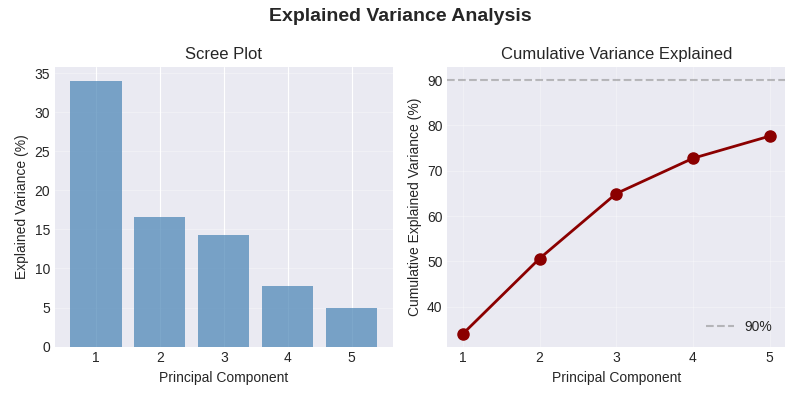

In [108]:
# Plot explained variance
fpca.plot_explained_variance(
    title='Explained Variance Analysis', 
    figsize=(8,4)
)
plt.show()


PROJECTING DATA

Conditions for projection:
  GO_R: epoch [-300, 600] ms, aligned to stop_cue
  CONT_R: epoch [-300, 600] ms, aligned to stop_cue
  STOP_R: epoch [-300, 600] ms, aligned to stop_cue
  ERROR_STOP_R: epoch [-300, 600] ms, aligned to stop_cue

Extracting PSTHs for 1281 neurons...


Processing GO_R: 100%|██████████| 1281/1281 [00:03<00:00, 365.38it/s]


(1281,), (1281, 900)
  GO_R: 1281/1281 neurons have data
 :X_condition mean 6.410514804650365, std 8.028083741638639
 :X_condition shape (1281, 900), means shape (1281, 1)
X_condition_normalized.shape: (1281, 900), PCA components shape: (5, 1281)
  Projection shape: (5, 900)


Processing CONT_R: 100%|██████████| 1281/1281 [00:03<00:00, 370.20it/s]


(1281,), (1281, 900)
  CONT_R: 1281/1281 neurons have data
 :X_condition mean 6.796572895826424, std 8.41237046352409
 :X_condition shape (1281, 900), means shape (1281, 1)
X_condition_normalized.shape: (1281, 900), PCA components shape: (5, 1281)
  Projection shape: (5, 900)


Processing STOP_R: 100%|██████████| 1281/1281 [00:03<00:00, 370.05it/s]


(1281,), (1281, 900)
  STOP_R: 1281/1281 neurons have data
 :X_condition mean 6.541989192248715, std 8.480558022574307
 :X_condition shape (1281, 900), means shape (1281, 1)
X_condition_normalized.shape: (1281, 900), PCA components shape: (5, 1281)
  Projection shape: (5, 900)


Processing ERROR_STOP_R: 100%|██████████| 1281/1281 [00:03<00:00, 370.60it/s]


(1281,), (1281, 900)
  ERROR_STOP_R: 1281/1281 neurons have data
 :X_condition mean 6.687415972403831, std 8.615738900653904
 :X_condition shape (1281, 900), means shape (1281, 1)
X_condition_normalized.shape: (1281, 900), PCA components shape: (5, 1281)
  Projection shape: (5, 900)

✓ Projection complete


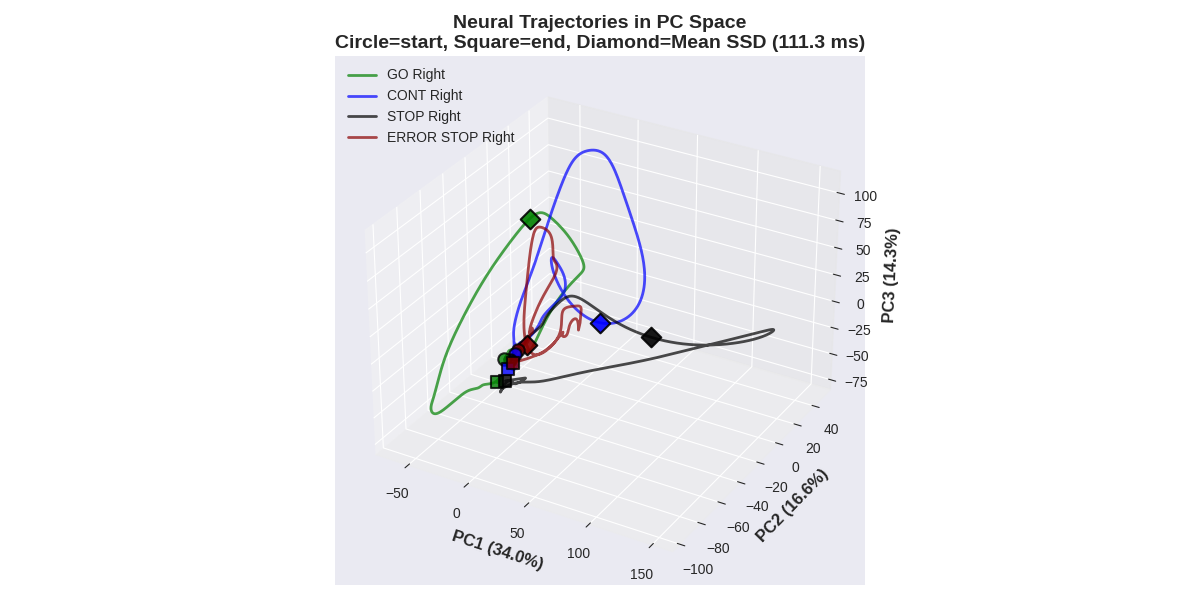

In [114]:
epochs_dict = {
    'go_cue': [-100, 600],
    'stop_cue': [-300, 600],
    'first_relevant_saccade': [-300, 300],
}

proj_alignment_pt= 'stop_cue'
is_slow = True
EPOCH = epochs_dict[proj_alignment_pt]
proj_specs = [
    TrialSpec(
        'GO', direction=CONTRA_DIR, epoch=EPOCH, alignment=proj_alignment_pt, 
        success_only=True, failed_only=False, is_slow_go=is_slow,
        # label='FAST_GO_R'
    ),
    TrialSpec(
        'CONT', direction=CONTRA_DIR, epoch=EPOCH, alignment=proj_alignment_pt,
        success_only=True, failed_only=False, is_slow_go=is_slow,
        # label='FAST_CONT_R'
    ),
]
proj_specs.append(TrialSpec(
        'STOP', direction=CONTRA_DIR, 
        epoch=EPOCH, alignment=proj_alignment_pt, 
        success_only=True, failed_only=False, is_slow_go=None,
))
proj_specs.append(TrialSpec(
        'STOP', direction=CONTRA_DIR, 
        epoch=EPOCH, alignment=proj_alignment_pt, 
        success_only=False, failed_only=True, is_slow_go=None,
        label='ERROR_STOP_R'
))
projections = fpca.project(proj_specs)
# projections.update(trajectories)
time_axes.update({label: fpca.get_time_axis(spec) for spec in proj_specs for label in [spec.get_label_for_direction(d) for d in spec.get_directions()]})

fpca.plot_3d_trajectories(
    # trajectories,
    projections,
    time_axes,
    # title='Neural Trajectories in 3D PC Space',
    figsize=(12, 6)
)
plt.show()

In [110]:
# # Plot 3D trajectories (mean SSD marker added automatically)
# # proj_specs = [
# #     TrialSpec('GO', direction=CONTRA_DIR, epoch=[-100, 250], alignment='stop_cue', ssd_number=None),
# #     TrialSpec('STOP', direction=CONTRA_DIR, epoch=[-100, 250], alignment='stop_cue', ssd_number=None, success_only=False, failed_only=True),
# #     TrialSpec('CONT', direction=CONTRA_DIR, epoch=[-100, 250], alignment='stop_cue', ssd_number=None),
# # ]

# # proj_specs = specs.copy()
# epochs_dict = {
#     'go_cue': [-100, 600],
#     'stop_cue': [-300, 600],
#     'first_relevant_saccade': [-300, 300],
# }
# # EPOCH = [-100, 600]
# for alignment in epochs_dict.keys():
#     for is_slow in [True, False]:
#         print(f"{alignment} epoch: {epochs_dict[alignment]}, is_slow: {is_slow} ")
#         proj_alignment_pt= alignment
#         # is_slow = True
#         EPOCH = epochs_dict[proj_alignment_pt]
#         proj_specs = [
#             TrialSpec(
#                 'GO', direction=CONTRA_DIR, epoch=EPOCH, alignment=proj_alignment_pt, 
#                 success_only=True, failed_only=False, is_slow_go=is_slow,
#                 # label='FAST_GO_R'
#             ),
#             TrialSpec(
#                 'CONT', direction=CONTRA_DIR, epoch=EPOCH, alignment=proj_alignment_pt,
#                 success_only=True, failed_only=False, is_slow_go=is_slow,
#                 # label='FAST_CONT_R'
#             ),
#         ]
#         proj_specs.append(TrialSpec(
#                 'STOP', direction=CONTRA_DIR, 
#                 epoch=EPOCH, alignment=proj_alignment_pt, 
#                 success_only=True, failed_only=False, is_slow_go=None,
#         ))
#         proj_specs.append(TrialSpec(
#                 'STOP', direction=CONTRA_DIR, 
#                 epoch=EPOCH, alignment=proj_alignment_pt, 
#                 success_only=False, failed_only=True, is_slow_go=None,
#                 label='ERROR_STOP_R'
#         ))
#         projections = fpca.project(proj_specs)
#         # projections.update(trajectories)
#         time_axes.update({label: fpca.get_time_axis(spec) for spec in proj_specs for label in [spec.get_label_for_direction(d) for d in spec.get_directions()]})

#         slow_str = 'SLOW' if is_slow else 'FAST'
#         fpca.plot_pc_timeseries(
#             # trajectories,
#             projections,
#             time_axes,
#             n_pcs=1,
#             title=f'PC1 trajectories over time aligned to {proj_alignment_pt}; **{slow_str}** GO & CONT',
#             figsize=(8, 3)
#         )
#         plt.show()

In [111]:
# fpca.cell_ids.shape, fpca.pca_model.components_.shape

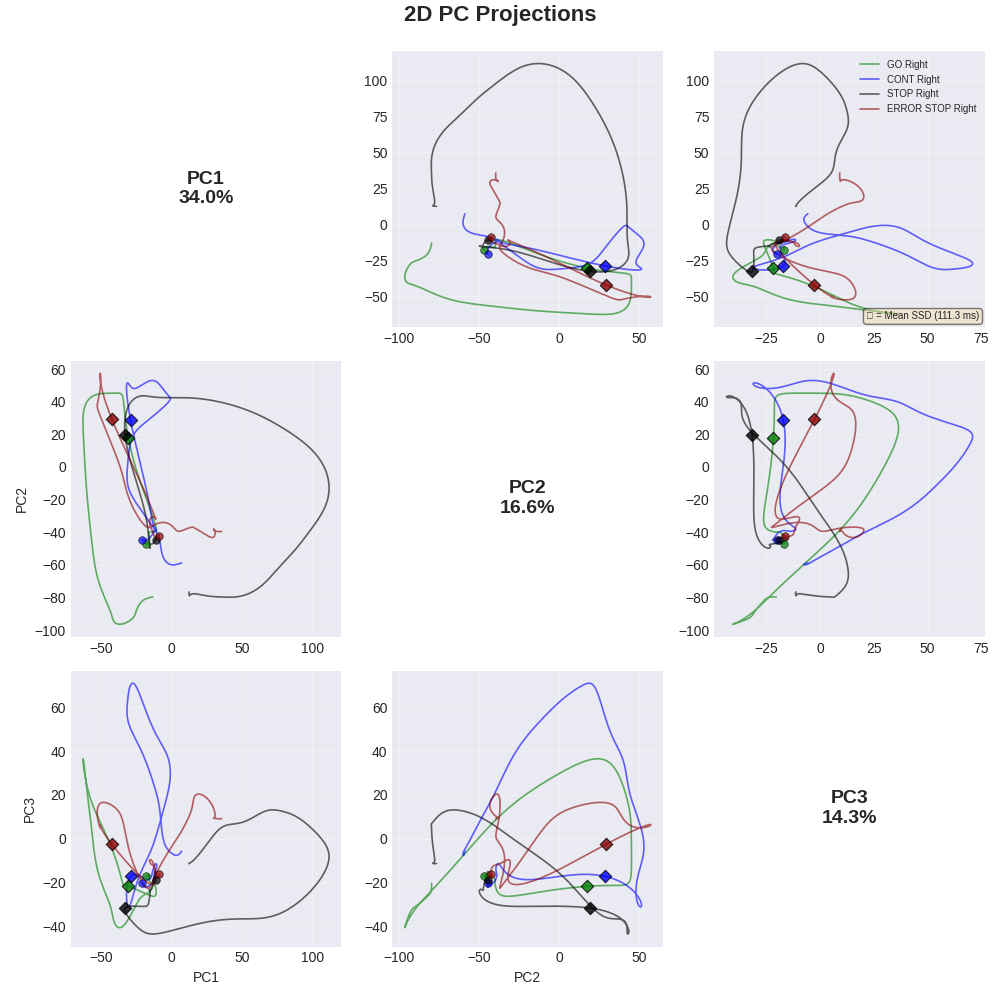

In [112]:
# Plot 2D projections matrix (mean SSD marker added automatically)
fpca.plot_2d_projections(
    # trajectories,
    projections,
    time_axes,
    n_pcs=3,
    title='2D PC Projections',
    figsize=(10, 10)
)
plt.show()

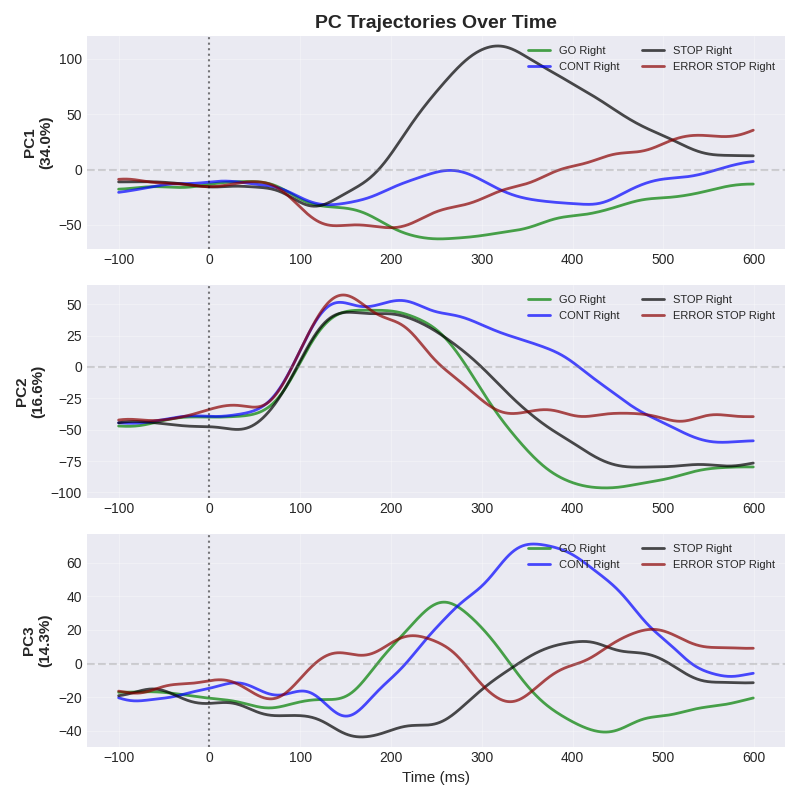

In [113]:
# Plot PC time series (mean SSD marker added automatically)
fpca.plot_pc_timeseries(
    # trajectories,
    projections,
    time_axes,
    n_pcs=3,
    title='PC Trajectories Over Time',
    figsize=(8, 8)
)
plt.show()